<a href="https://colab.research.google.com/github/mryiadom/Quant-Finance-Path/blob/main/Week_03_Probability_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Logic Steps:

1. Define the Parameters: How many sides ($n$) and how many trials ($N$).

2. Generate Random Data: Use numpy.random.randint to simulate $N$ rolls.

3. Calculate Metrics: Find the mean and variance of your sample.

4. Visualise: Plot the frequency of each result to see if it looks "Uniform."

We use Numpy over for loops for a more efficient approach. In the quant world. speed is everything


Python List: Iterative (One by one).

NumPy Array: Parallel (All at once).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

In [ ]:
# Parameters
n_sides = 6          # The "n" in our probability formula
n_simulations = 10000 # The "N" trials

In [ ]:
# Generate 10,000 random numbers between 1 and 6
rolls = np.random.randint(low=1, high=n_sides + 1, size=n_simulations)

In [ ]:
# Calculate the average (Mean)
sample_mean = np.mean(rolls)

print(f"The average roll was: {sample_mean}")
# We expect this to be close to 3.5!

The average roll was: 3.4809


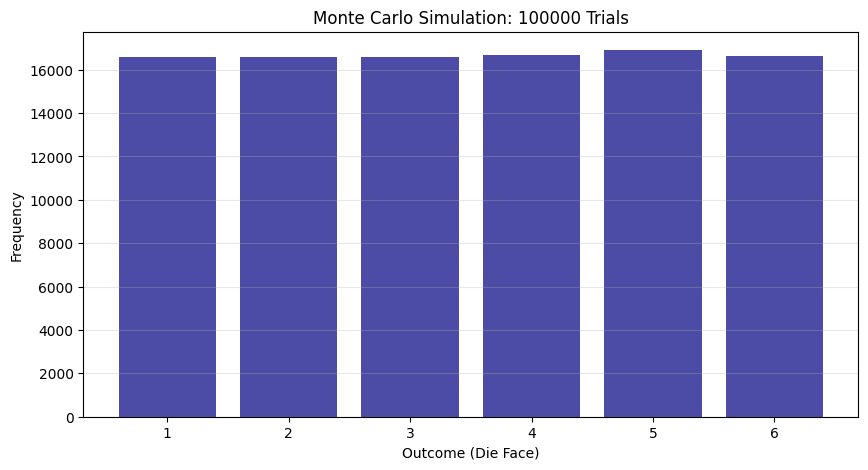

Deliverable Complete.
Sample Mean: 3.5065 | Sample Variance: 2.9135


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

def run_monte_carlo_dice_simulator(n_sides: int = 6, n_sims: int = 10000) -> Tuple[float, float]:
    """
    Deliverable: Week 3 - Monte Carlo Dice Simulator.
    Simulates dice rolls to demonstrate the Law of Large Numbers.
    """
    # 1. Action: Generate random data using NumPy Vectorisation
    rolls: np.ndarray = np.random.randint(low=1, high=n_sides + 1, size=n_sims)

    # 2. Analysis: Compute Sample Statistics
    sample_mean: float = np.mean(rolls)
    sample_variance: float = np.var(rolls)

    # 3. Visualisation: Check for a Discrete Uniform Distribution
    plt.figure(figsize=(10, 5))
    plt.hist(rolls, bins=np.arange(1, n_sides + 2) - 0.5, rwidth=0.8, color='navy', alpha=0.7)
    plt.title(f"Monte Carlo Simulation: {n_sims} Trials")
    plt.xlabel("Outcome (Die Face)")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    return sample_mean, sample_variance

# Run the simulation
if __name__ == "__main__":
    avg, var = run_monte_carlo_dice_simulator(n_sides=6, n_sims=100000)
    print(f"Deliverable Complete.")
    print(f"Sample Mean: {avg:.4f} | Sample Variance: {var:.4f}")

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd

In [ ]:
ticker = 'NVDA'
stock = yf.download(tickers=ticker, start='2025-01-01', end='2026-03-07', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [ ]:
def calculate_stock_movement(ticker, start_date, end_date):

  stock = yf.download(tickers=ticker, start=start_date, end=end_date, auto_adjust=True)

  returns = np.array(stock['Close'].pct_change().dropna())

  mean = np.mean(returns)
  daily_std = np.std(returns)
  annual_vol = daily_std * np.sqrt(252)

  print(f"\nThe mean return of {ticker} is {mean:.6f}")
  print(f"The daily std is {daily_std:.6f}")
  print(f"The Annualised Volatility is {annual_vol:.2%}")

  return mean, daily_std, annual_vol, returns, stock

In [ ]:
mean, daily_std, annual_vol, returns, stock = calculate_stock_movement(ticker = 'NVDA', start_date = '2025-01-01', end_date = '2026-03-07')

[*********************100%***********************]  1 of 1 completed


The mean return of NVDA is 0.001315
The daily std is 0.030142
The Annualised Volatility is 47.85%


In [ ]:
daily_std = np.std(returns)
annual_vol = daily_std * np.sqrt(252)
#we use 252 days as in the uk and us we assume 252 trading days in a year

In [ ]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-01-02,138.272171,138.842022,134.593185,135.962805,198247200
2025-01-03,144.430496,144.860371,139.691787,139.971709,229322500
2025-01-06,149.389130,152.118394,147.779585,148.549363,265377400
2025-01-07,140.101669,153.088122,139.971700,152.988143,351782200
2025-01-08,140.071701,143.910648,137.522395,142.541027,227349900


In [ ]:
stock['Close']

Ticker,NVDA
Date,
2025-01-02,138.272171
2025-01-03,144.430496
2025-01-06,149.389130
2025-01-07,140.101669
2025-01-08,140.071701
...,...
2026-03-02,182.479996
2026-03-03,180.050003
2026-03-04,183.039993


In [ ]:
returns = stock['Close'].pct_change().dropna()

In [ ]:
returns

Ticker,NVDA
Date,
2025-01-03,0.044538
2025-01-06,0.034332
2025-01-07,-0.062170
2025-01-08,-0.000214
2025-01-10,-0.029976
...,...
2026-03-02,0.029855
2026-03-03,-0.013316
2026-03-04,0.016606


In [ ]:
'''
A Standard Deviation ($\sigma$) tells us how far, on average, the daily
returns stray from your mean of 0.16%

Annualisation allows you to compare NVDA's risk to other assets (like Bonds
 or the FTSE 100) on a level playing field
'''

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1382/1651918529.py:2: SyntaxWarning: invalid escape sequence '\s'
  A Standard Deviation ($\sigma$) tells us how far, on average, the daily


"\nA Standard Deviation ($\\sigma$) tells us how far, on average, the daily\nreturns stray from your mean of 0.16%\n\nAnnualisation allows you to compare NVDA's risk to other assets (like Bonds\n or the FTSE 100) on a level playing field\n"

In [ ]:
# 1. Setup the Simulation
n_sims = 1000000
n_days = 30
start_price = 100 # We'll use $100 as a base for easy math

# 2. Generate the "Rolls"
# This creates a matrix of 30 days x 10,000 universes
daily_rolls = np.random.normal(loc=mean, scale=daily_std, size=(n_days, n_sims))

# 3. Create the Price Paths
# (1 + rolls) converts a 3% gain into 1.03.
# cumprod(axis=0) multiplies them day-by-day down the 30 days.
price_paths = start_price * np.cumprod(1 + daily_rolls, axis=0)

# 4. Analysis: What is the average price after 30 days?
final_prices = price_paths[-1, :] # Grab the last row (Day 30)
expected_value = np.mean(final_prices)

print(f"Starting Price: we £{start_price}")
print(f"Average Final Price after 30 days: £{expected_value:.2f}")

Starting Price: we £100
Average Final Price after 30 days: £104.02


In [23]:
n_sims = 1000000
n_days = 30
start_price = 100

# The Matrix: 30 rows (days) by 100,000 columns (universes)
daily_rolls = np.random.normal(loc=mean, scale=daily_std, size=(n_days, n_sims))
price_paths = start_price * np.cumprod(1 + daily_rolls, axis=0)

final_prices = price_paths[-1, :]

print(f"--- Results for {n_sims:,} Simulations ---")
print(f"Average Final Price: ${np.mean(final_prices):.2f}")
print(f"Max (Moon Mission): ${np.max(final_prices):.2f}")
print(f"Min (Total Crash):  ${np.min(final_prices):.2f}")

--- Results for 1,000,000 Simulations ---
Average Final Price: $104.00
Max (Moon Mission): $223.58
Min (Total Crash):  $46.06


In [21]:
print(f"Median Final Price: ${np.median(final_prices):.2f}")

Median Final Price: $102.67
